#  — Evaluation

This notebook analyzes the forecasting results generated by:

- `02_baselines.ipynb`
- `03_chronos2_forecasting.ipynb`

No models are trained or refitted in this notebook.

The analysis includes:

- MAE comparison
- RMSE comparison
- Model comparison
- Forecast-horizon comparison
- Actual vs forecast visualization
- Baseline improvement
- Final model ranking

## Imports

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.evaluation import (
    load_metrics,
    load_forecasts,
    sort_results,
    get_best_model,
    compare_models,
    compare_by_horizon,
    plot_metric_comparison,
    plot_horizon_comparison,
)

## Paths

In [2]:
RESULTS_DIR = PROJECT_ROOT / "results"

METRICS_PATH = (
    RESULTS_DIR / "metrics.csv"
)

FORECASTS_PATH = (
    RESULTS_DIR / "forecasts.csv"
)

print("Results directory:")
print(RESULTS_DIR)

Results directory:
c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\results


## Load previous results

In [3]:
metrics = load_metrics(
    METRICS_PATH
)

display(metrics)

,Model,Series_ID,Horizon,MAE,RMSE
0,Naive Seasonal (Daily),MT_001,96,1.136844,2.795961
1,Naive Seasonal (Daily),MT_001,192,1.083968,2.450641
2,Naive Seasonal (Daily),MT_001,672,1.136844,2.409219
3,"ARIMA(12,1,0)",MT_001,96,0.756977,0.978251
4,Chronos-2,MT_001,96,0.763720,1.182067
5,Chronos-2,MT_001,192,0.795465,1.208076
6,Chronos-2,MT_001,672,0.964219,1.799736


## Inspect Metrics

In [4]:
print("Number of experiments:", len(metrics))

print(
    "\nModels:"
)

print(
    metrics["Model"].unique()
)

print(
    "\nHorizons:"
)

print(
    metrics["Horizon"].unique()
)

Number of experiments: 7

Models:
<StringArray>
['Naive Seasonal (Daily)', 'ARIMA(12,1,0)', 'Chronos-2']
Length: 3, dtype: str

Horizons:
[ 96 192 672]


## Sort Models

In [5]:
sorted_metrics = sort_results(
    metrics,
    metric="RMSE",
)

display(
    sorted_metrics
)

,Model,Series_ID,Horizon,MAE,RMSE
0,"ARIMA(12,1,0)",MT_001,96,0.756977,0.978251
1,Chronos-2,MT_001,96,0.763720,1.182067
2,Chronos-2,MT_001,192,0.795465,1.208076
3,Chronos-2,MT_001,672,0.964219,1.799736
4,Naive Seasonal (Daily),MT_001,672,1.136844,2.409219
5,Naive Seasonal (Daily),MT_001,192,1.083968,2.450641
6,Naive Seasonal (Daily),MT_001,96,1.136844,2.795961


## Best Model

In [6]:
best_by_horizon = (
    metrics
    .sort_values("RMSE")
    .groupby("Horizon", as_index=False)
    .first()
)

display(best_by_horizon)

,Horizon,Model,Series_ID,MAE,RMSE
0,96,"ARIMA(12,1,0)",MT_001,0.756977,0.978251
1,192,Chronos-2,MT_001,0.795465,1.208076
2,672,Chronos-2,MT_001,0.964219,1.799736


In [7]:
model_comparison = compare_models(
    metrics
)

display(
    model_comparison
)

,Model,MAE,RMSE
0,"ARIMA(12,1,0)",0.756977,0.978251
1,Chronos-2,0.841135,1.396626
2,Naive Seasonal (Daily),1.119219,2.551940


## Horizon Comparision

In [8]:
horizon_comparison = compare_by_horizon(
    metrics
)

display(
    horizon_comparison
)

,Horizon,Model,MAE,RMSE
0,96,"ARIMA(12,1,0)",0.756977,0.978251
1,96,Chronos-2,0.763720,1.182067
2,96,Naive Seasonal (Daily),1.136844,2.795961
3,192,Chronos-2,0.795465,1.208076
4,192,Naive Seasonal (Daily),1.083968,2.450641
5,672,Chronos-2,0.964219,1.799736
6,672,Naive Seasonal (Daily),1.136844,2.409219


## MAE Comparision

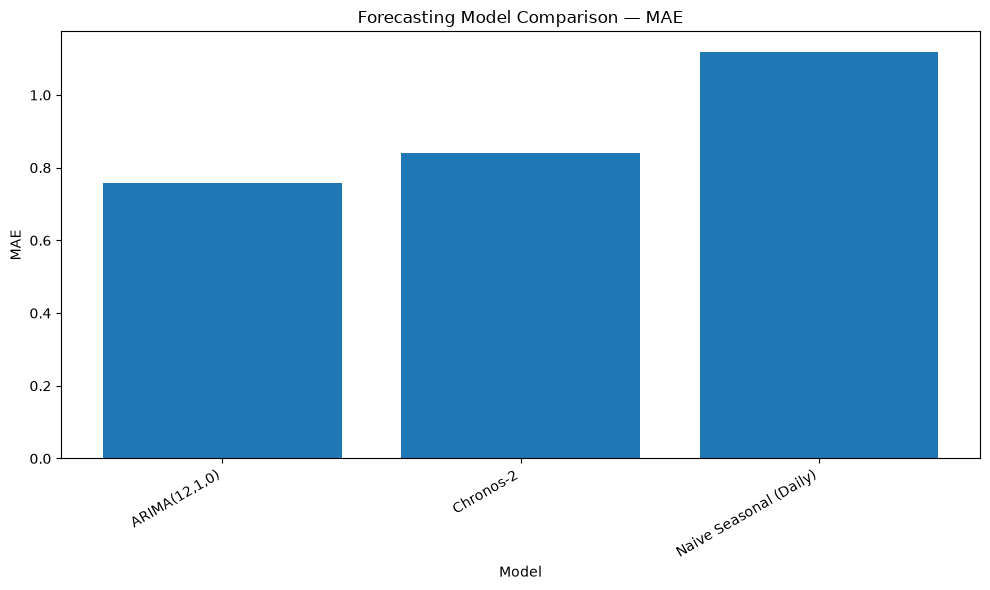

In [9]:
plot_metric_comparison(
    metrics,
    metric="MAE",
    title="Forecasting Model Comparison — MAE",
)

## RMSE Comparision

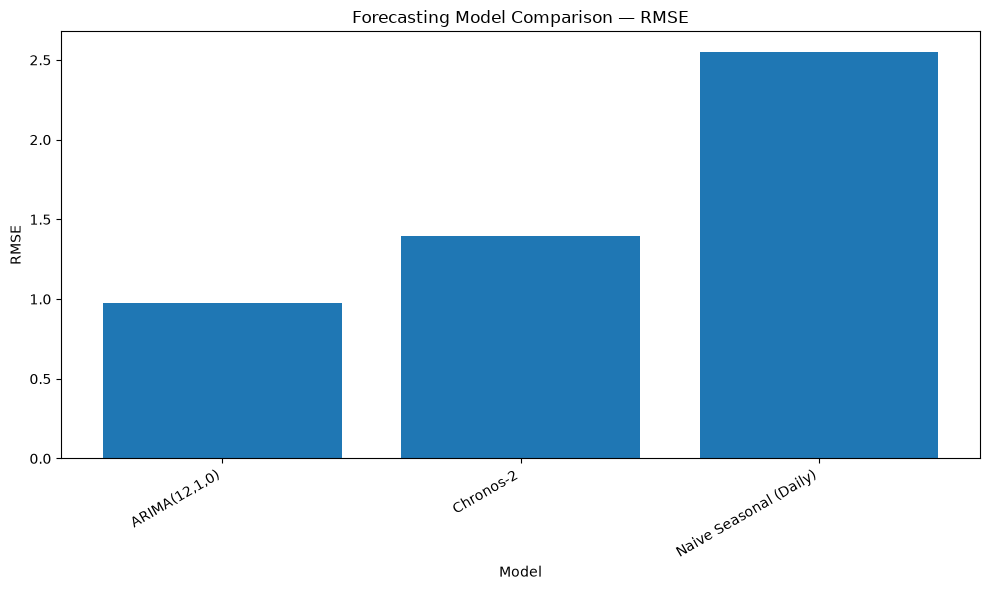

In [10]:
plot_metric_comparison(
    metrics,
    metric="RMSE",
    title="Forecasting Model Comparison — RMSE",
)

## Horizon Performance

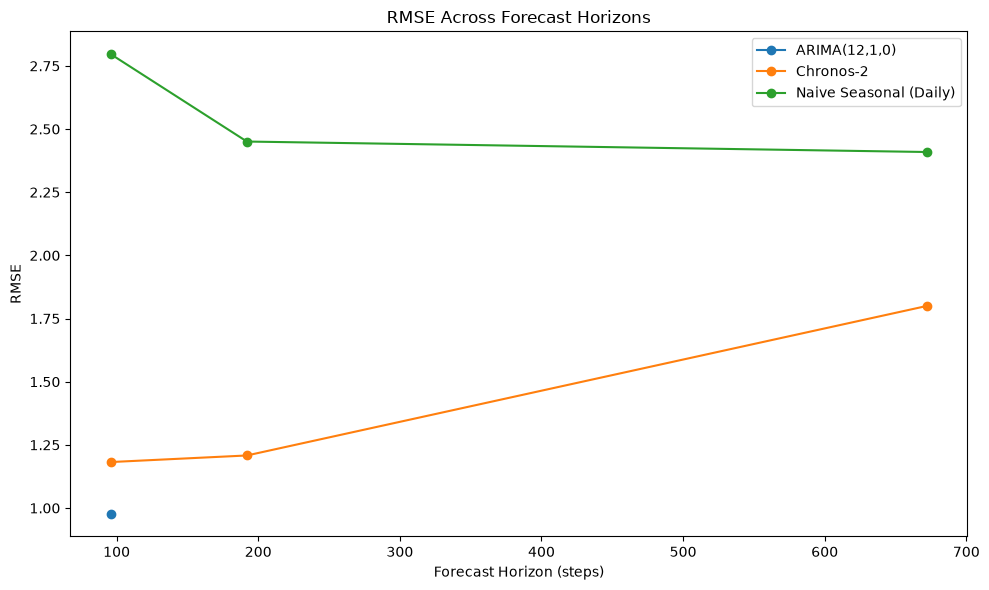

In [11]:
plot_horizon_comparison(
    metrics,
    metric="RMSE",
)

## Load Forecasts

In [12]:
import pandas as pd
print(pd.read_csv(FORECASTS_PATH, nrows=2).columns.tolist())

['timestamp', 'series_id', 'model_name', 'horizon', 'value']


In [13]:
forecasts = pd.read_csv(
    FORECASTS_PATH,
    header=None,
    names=["timestamp", "series_id", "model_name", "horizon", "value"],
    parse_dates=["timestamp"],
)

display(
    forecasts.head()
)

print(
    "Forecast rows:",
    len(forecasts)
)

C:\Users\palla\AppData\Local\Temp\ipykernel_6752\947521525.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  forecasts = pd.read_csv(


,timestamp,series_id,model_name,horizon,value
0,timestamp,series_id,model_name,horizon,value
1,2014-03-14 19:15:00,MT_001,Naive Seasonal (Daily),96,2.53807106598985
2,2014-03-14 19:30:00,MT_001,Naive Seasonal (Daily),96,1.26903553299492
3,2014-03-14 19:45:00,MT_001,Naive Seasonal (Daily),96,2.53807106598985
4,2014-03-14 20:00:00,MT_001,Naive Seasonal (Daily),96,2.53807106598985


Forecast rows: 2017


## Forecast Metadata

In [14]:
print(forecasts.columns.tolist())

['timestamp', 'series_id', 'model_name', 'horizon', 'value']


In [15]:
print("Models:")
display(forecasts["model_name"].unique())

print("\nHorizons:")
display(forecasts["horizon"].unique())

Models:


<StringArray>
['model_name', 'Naive Seasonal (Daily)', 'ARIMA(12,1,0)', 'Chronos-2']
Length: 4, dtype: str


Horizons:


<StringArray>
['horizon', '96', '192', '672']
Length: 4, dtype: str

## Forecast Visualization

In [16]:
actuals = pd.read_csv(
    RESULTS_DIR / "actuals.csv",
    parse_dates=["timestamp"],
)

horizon = 96

actual_24h = actuals[
    actuals["horizon"] == horizon
].copy()

forecast_24h = forecasts[
    forecasts["horizon"] == horizon
].copy()

In [17]:
import os
print(os.path.exists(RESULTS_DIR / "forecasts.csv"))
print(os.path.getsize(RESULTS_DIR / "forecasts.csv") if (RESULTS_DIR / "forecasts.csv").exists() else "missing")

True
132671


In [18]:
forecasts = pd.read_csv(RESULTS_DIR / "forecasts.csv", parse_dates=["timestamp"])
print(len(forecasts))
display(forecasts.head())

2016


,timestamp,series_id,model_name,horizon,value
0,2014-03-14 19:15:00,MT_001,Naive Seasonal (Daily),96,2.538071
1,2014-03-14 19:30:00,MT_001,Naive Seasonal (Daily),96,1.269036
2,2014-03-14 19:45:00,MT_001,Naive Seasonal (Daily),96,2.538071
3,2014-03-14 20:00:00,MT_001,Naive Seasonal (Daily),96,2.538071
4,2014-03-14 20:15:00,MT_001,Naive Seasonal (Daily),96,1.269036


In [19]:
print(forecasts["horizon"].dtype)
print(forecasts["horizon"].unique())

horizon = 96
forecast_24h = forecasts[forecasts["horizon"] == horizon].copy()
print(len(forecast_24h))
display(forecast_24h.head())

int64
[ 96 192 672]
288


,timestamp,series_id,model_name,horizon,value
0,2014-03-14 19:15:00,MT_001,Naive Seasonal (Daily),96,2.538071
1,2014-03-14 19:30:00,MT_001,Naive Seasonal (Daily),96,1.269036
2,2014-03-14 19:45:00,MT_001,Naive Seasonal (Daily),96,2.538071
3,2014-03-14 20:00:00,MT_001,Naive Seasonal (Daily),96,2.538071
4,2014-03-14 20:15:00,MT_001,Naive Seasonal (Daily),96,1.269036


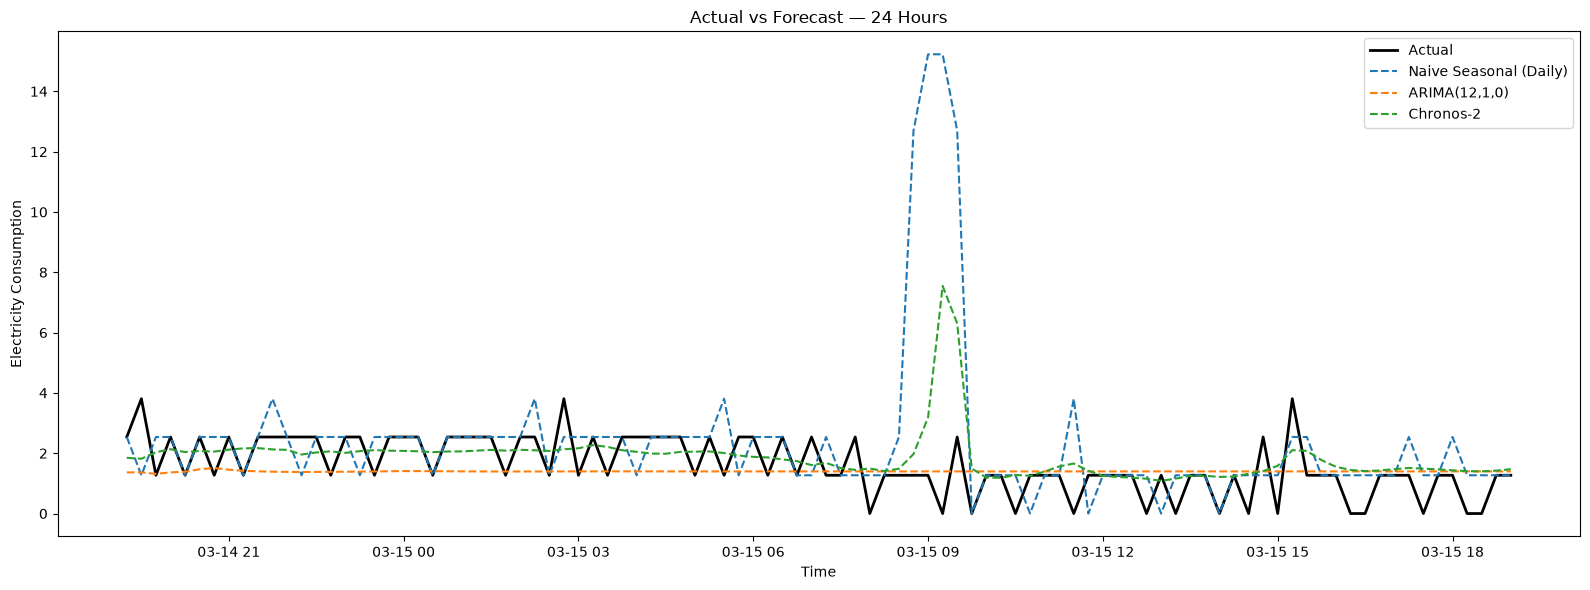

In [20]:
plt.figure(figsize=(16, 6))

plt.plot(
    actual_24h["timestamp"],
    actual_24h["value"],
    label="Actual",
    color="black",
    linewidth=2,
)

for model_name in forecast_24h["model_name"].unique():
    model_data = forecast_24h[
        forecast_24h["model_name"] == model_name
    ]
    plt.plot(
        model_data["timestamp"],
        model_data["value"],
        label=model_name,
        linestyle="--",
    )

plt.title("Actual vs Forecast — 24 Hours")
plt.xlabel("Time")
plt.ylabel("Electricity Consumption")
plt.legend()
plt.tight_layout()
plt.show()

## Calculating improvement

In [21]:
from src.evaluation import calculate_improvement

improvement = calculate_improvement(
    metrics,
    baseline_model="Naive Seasonal (Daily)",
    metric="RMSE",
)

display(improvement)

,Model,Series_ID,Horizon,MAE,RMSE,Baseline_RMSE,Improvement_%
0,Naive Seasonal (Daily),MT_001,96,1.136844,2.795961,2.795961,0.000000
1,Naive Seasonal (Daily),MT_001,192,1.083968,2.450641,2.450641,0.000000
2,Naive Seasonal (Daily),MT_001,672,1.136844,2.409219,2.409219,0.000000
3,"ARIMA(12,1,0)",MT_001,96,0.756977,0.978251,2.795961,65.012008
4,Chronos-2,MT_001,96,0.763720,1.182067,2.795961,57.722346
5,Chronos-2,MT_001,192,0.795465,1.208076,2.450641,50.703653
6,Chronos-2,MT_001,672,0.964219,1.799736,2.409219,25.297938
